In [65]:
from Utils_app import*
from Utils_eda import(analyze_cutoff_impact)

In [66]:
import pandas as pd

In [88]:
df = pd.read_csv('data/ratings.csv')

In [89]:
df = add_datetime_features(df, timestamp_col="timestamp")

print(df[["timestamp", "datetime", "year", "month", "day"]].head())

    timestamp            datetime  year  month  day
0  1260759144 2009-12-14 02:52:24  2009     12   14
1  1260759179 2009-12-14 02:52:59  2009     12   14
2  1260759182 2009-12-14 02:53:02  2009     12   14
3  1260759185 2009-12-14 02:53:05  2009     12   14
4  1260759205 2009-12-14 02:53:25  2009     12   14


In [90]:
df_cleaned = clean_rating_dataset(df, timestamp_cols=["timestamp"], rating_col="rating")

=== Initial dataset statistics ===
Dataset statistics:
  Rows: 100004
  Unique users: 671
  Unique products: 9066
  Avg ratings per user: 149.04
  Avg ratings per product: 11.03
Removed 5 rows containing nulls (excluding timestamp columns).
Removed 0 duplicate user-product ratings.
Removed 2 rows with min (-1.0) or max (99.0) ratings.
=== Final cleaned dataset statistics ===
Dataset statistics:
  Rows: 99997
  Unique users: 671
  Unique products: 9066
  Avg ratings per user: 149.03
  Avg ratings per product: 11.03


In [98]:
filtered_df=analyze_cutoff_impact(df_cleaned, product_min_ratings=7, user_low_n=10)

Unique values per column:
  user_id: 671
  product_id: 9066
  rating: 10
=== 1. Product rating counts BEFORE filtering ===
count    9066.000000
mean       11.029892
std        24.049299
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       341.000000
Name: count, dtype: float64

Products with < 7 ratings: 6273

Records BEFORE filtering: 99997
Records AFTER filtering: 86245
Removed: 13752 records (13.75%)

=== 2. User activity (ratings per user) AFTER filtering ===
Total unique users after filtering: 671

=== Lowest 10 activity levels (explained) ===

Columns:
ratings_per_user -> number of ratings a user made
num_users -> number of users with that number of ratings

Unique values per column:
  user_id: 671
  product_id: 2793
  rating: 10
ratings_per_user = 13 → num_users = 1
ratings_per_user = 17 → num_users = 4
ratings_per_user = 18 → num_users = 2
ratings_per_user = 19 → num_users = 11
ratings_per_user = 20 → num_users = 26
ratings_per_user = 21

In [99]:
filtered_df.head()

,user_id,product_id,rating,timestamp,datetime,year,month,day
0,1.0,31.0,2.5,1260759144,2009-12-14 02:52:24,2009,12,14
1,1.0,1029.0,3.0,1260759179,2009-12-14 02:52:59,2009,12,14
2,1.0,1061.0,3.0,1260759182,2009-12-14 02:53:02,2009,12,14
3,1.0,1129.0,2.0,1260759185,2009-12-14 02:53:05,2009,12,14
4,1.0,1172.0,4.0,1260759205,2009-12-14 02:53:25,2009,12,14


In [107]:
filtered_df

,user_id,product_id,rating,timestamp,datetime,year,month,day
0,1.0,31.0,2.5,1260759144,2009-12-14 02:52:24,2009,12,14
1,1.0,1029.0,3.0,1260759179,2009-12-14 02:52:59,2009,12,14
2,1.0,1061.0,3.0,1260759182,2009-12-14 02:53:02,2009,12,14
3,1.0,1129.0,2.0,1260759185,2009-12-14 02:53:05,2009,12,14
4,1.0,1172.0,4.0,1260759205,2009-12-14 02:53:25,2009,12,14
...,...,...,...,...,...,...,...,...
99998,671.0,6212.0,2.5,1065149436,2003-10-03 02:50:36,2003,10,3
100000,671.0,6269.0,4.0,1065149201,2003-10-03 02:46:41,2003,10,3
100001,671.0,6365.0,4.0,1070940363,2003-12-09 03:26:03,2003,12,9
100002,671.0,6385.0,2.5,1070979663,2003-12-09 14:21:03,2003,12,9


In [111]:
print(df.dtypes)
print(df.isna().sum())
df = df.dropna(subset=['rating'])
df['rating'] = df['rating'].astype(float)
df = df.dropna(subset=['rating'])

user_id              float64
product_id           float64
rating               float64
timestamp              int64
datetime      datetime64[ns]
year                   Int64
month                  Int64
day                    Int64
dtype: object
user_id       0
product_id    0
rating        0
timestamp     0
datetime      0
year          0
month         0
day           0
dtype: int64


SVD RMSE: 2.3566, MAE: 2.0303
Item-Based CF RMSE: 340.3721, MAE: 266.1914


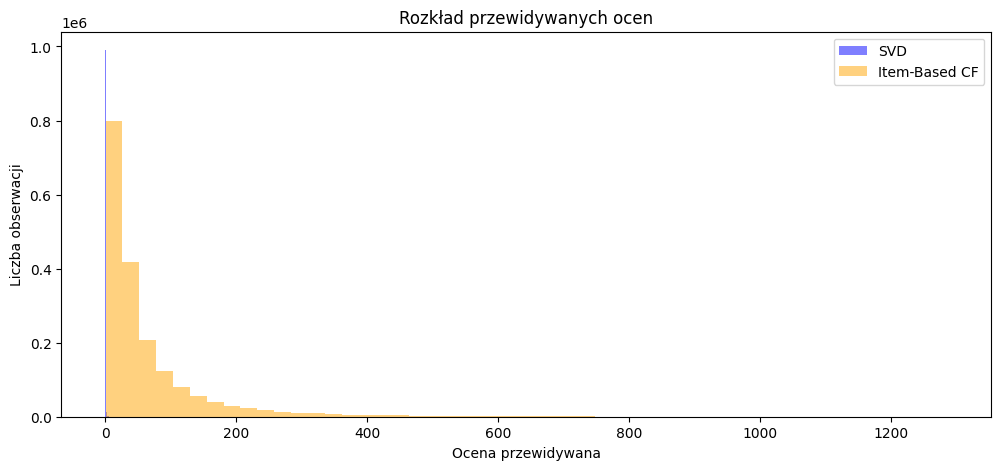

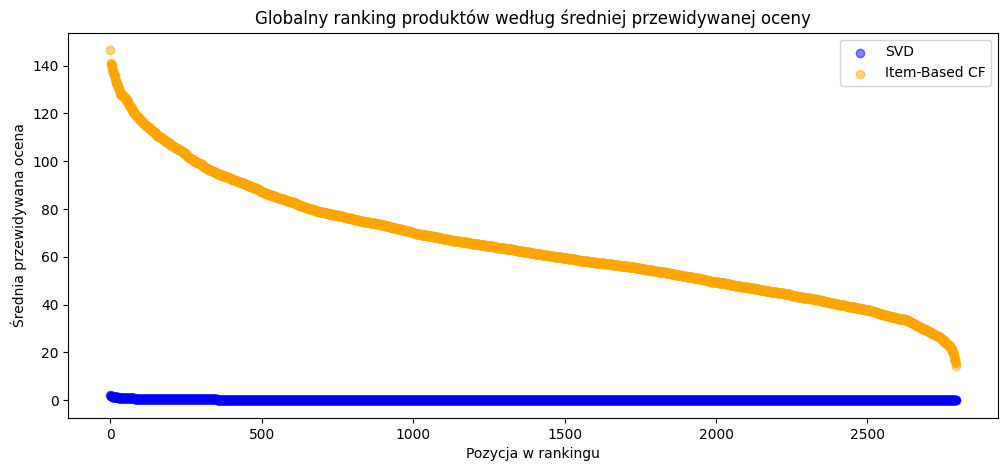


SVD TOP-20 dla użytkownika 1.0: [1374.0, 1282.0, 1214.0, 596.0, 750.0, 1272.0, 1276.0, 1208.0, 2529.0, 594.0, 1079.0, 1090.0, 1275.0, 1204.0, 1222.0, 1965.0, 1136.0, 1262.0, 1221.0, 1080.0]
Item-Based CF TOP-20 dla użytkownika 1.0: [1387.0, 1266.0, 2194.0, 1214.0, 3108.0, 1282.0, 1394.0, 2797.0, 1225.0, 2174.0, 919.0, 2987.0, 1302.0, 2289.0, 2366.0, 1097.0, 1234.0, 1208.0, 1252.0, 1079.0]


In [126]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# 1️⃣ Wczytanie danych
df = filtered_df  # kolumny: user_id, product_id, ratings

df = df.groupby(['user_id', 'product_id'], as_index=False)['rating'].mean()

# 2️⃣ Tworzymy macierz użytkownik x produkt
user_item_matrix = df.pivot(index='user_id', columns='product_id', values='rating').fillna(0)

# 3️⃣ SVD
n_components = 20
svd = TruncatedSVD(n_components=n_components, random_state=42)
svd_latent = svd.fit_transform(user_item_matrix)
approx_matrix = svd_latent @ svd.components_

def svd_recommend(user_id, top_n=20):
    user_idx = user_item_matrix.index.get_loc(user_id)
    user_scores = approx_matrix[user_idx].copy()
    already_rated = user_item_matrix.iloc[user_idx] > 0
    user_scores[already_rated] = -np.inf
    top_items = user_item_matrix.columns[np.argsort(user_scores)[-top_n:][::-1]]
    return top_items.tolist()

# 4️⃣ Item-Based CF
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

def item_based_recommend(user_id, top_n=20):
    user_ratings = user_item_matrix.loc[user_id]
    scores = user_ratings.values @ item_similarity
    scores = pd.Series(scores, index=user_item_matrix.columns)
    scores = scores[user_ratings == 0]
    return scores.sort_values(ascending=False).head(top_n).index.tolist()

# 5️⃣ RMSE i MAE
mask = user_item_matrix.values > 0

rmse_svd = np.sqrt(np.mean((approx_matrix[mask] - user_item_matrix.values[mask])**2))
mae_svd = np.mean(np.abs(approx_matrix[mask] - user_item_matrix.values[mask]))

ibcf_pred_matrix = user_item_matrix.values @ item_similarity
rmse_ibcf = np.sqrt(np.mean((ibcf_pred_matrix[mask] - user_item_matrix.values[mask])**2))
mae_ibcf = np.mean(np.abs(ibcf_pred_matrix[mask] - user_item_matrix.values[mask]))

# 6️⃣ Średnia przewidywana ocena dla produktów (globalny ranking)
svd_avg_pred = approx_matrix.mean(axis=0)
ibcf_avg_pred = ibcf_pred_matrix.mean(axis=0)

# 7️⃣ Wyniki
print(f"SVD RMSE: {rmse_svd:.4f}, MAE: {mae_svd:.4f}")
print(f"Item-Based CF RMSE: {rmse_ibcf:.4f}, MAE: {mae_ibcf:.4f}")

# 8️⃣ Wizualizacja przewidywanych ocen
plt.figure(figsize=(12,5))
plt.hist(approx_matrix.flatten(), bins=50, alpha=0.5, label='SVD', color='blue')
plt.hist(ibcf_pred_matrix.flatten(), bins=50, alpha=0.5, label='Item-Based CF', color='orange')
plt.title("Rozkład przewidywanych ocen")
plt.xlabel("Ocena przewidywana")
plt.ylabel("Liczba obserwacji")
plt.legend()
plt.show()

# 9️⃣ Wizualizacja globalnego rankingu produktów
plt.figure(figsize=(12,5))
plt.scatter(range(len(svd_avg_pred)), np.sort(svd_avg_pred)[::-1], label='SVD', color='blue', alpha=0.5)
plt.scatter(range(len(ibcf_avg_pred)), np.sort(ibcf_avg_pred)[::-1], label='Item-Based CF', color='orange', alpha=0.5)
plt.title("Globalny ranking produktów według średniej przewidywanej oceny")
plt.xlabel("Pozycja w rankingu")
plt.ylabel("Średnia przewidywana ocena")
plt.legend()
plt.show()

# 10️⃣ Przykładowe rekomendacje
example_user = df['user_id'].iloc[0]
print(f"\nSVD TOP-20 dla użytkownika {example_user}: {svd_recommend(example_user)}")
print(f"Item-Based CF TOP-20 dla użytkownika {example_user}: {item_based_recommend(example_user)}")